# CS5228 · 01 Data Audit, Cleaning & Exploratory Data Analysis (EDA)

**Task**: predict the monthly rent of Singapore HDB flats (`MONTHLY_RENT`, SGD); the Kaggle evaluation metric is RMSE.

This notebook works on the cleaned data produced by `src/data_cleaning.py` (`data/processed/processed_train.csv` / `processed_test.csv`) and covers:

1. Data audit summary (fields, missing values, duplicates, constant columns, train/test split)
2. Distribution of the target variable (rent)
3. Monthly rent trend
4. Town vs rent
5. Flat type / flat model vs rent
6. Floor area vs rent
7. Flat age vs rent
8. Train/test distribution differences

All figures are saved to `outputs/figures/eda_*.png` (figure text is in English for direct reuse in the report).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "data_cleaning.py").exists():
            return p
    raise FileNotFoundError("cannot locate repo root (looked for data/train.csv)")


ROOT = find_repo_root()
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

import sys
sys.path.insert(0, str(ROOT / "src"))
from data_cleaning import clean_data, audit_report

# Always regenerate from raw data; stale processed files cannot affect EDA.
train, test = clean_data()

def save(fig, name):
    path = FIG_DIR / name
    fig.savefig(path)
    print(f"saved: {path.relative_to(ROOT)}")

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} cols")
print(f"test : {test.shape[0]:,} rows x {test.shape[1]} cols")
train.head(3)

Data audit & cleaning report
rows: train=150,000  test=50,000
missing values: train=0  test=0
constant columns dropped: ['FURNISHED', 'FEE']
exact duplicate excess rows in train: 641; dropped: 0
duplicate feature excess rows in train: 21,974; feature groups with conflicting rent: 17,900
exact duplicate rows in test (kept, one prediction per Id): 7,764
MONTHLY_RENT: min=300 median=2700 max=7600 | <500 SGD: 12 | >6000 SGD: 24
FLAT_AGE < 0 (kept, documented): 1
train dates: 2021-01 .. 2025-03
test  dates: 2025-03 .. 2026-07
flat types after normalisation (6): 1-room, 2-room, 3-room, 4-room, 5-room, executive



wrote: C:\Files\Academic\NUS MSC(DSML)\CS5228 Knowledge Discovery and Data Mining\Project\cs5228\data\processed\processed_train.csv (150,000 rows x 13 cols)
wrote: C:\Files\Academic\NUS MSC(DSML)\CS5228 Knowledge Discovery and Data Mining\Project\cs5228\data\processed\processed_test.csv (50,000 rows x 12 cols)
train: 150,000 rows x 13 cols
test : 50,000 rows x 12 cols


,RENT_APPROVAL_DATE,RENT_APPROVAL_YEAR,RENT_APPROVAL_MONTH,RENT_APPROVAL_DT,TOWN,BLOCK,STREET,FLAT_TYPE,FLAT_MODEL,FLOOR_AREA_SQM,LEASE_COMMENCE_DATE,FLAT_AGE,MONTHLY_RENT
0,2021-01,2021,1,2021-01-01,punggol,604A,punggol road,4-room,model a,93.0,2012,9,1800
1,2021-01,2021,1,2021-01-01,sengkang,290C,compassvale crescent,5-room,improved,110.0,2001,20,2000
2,2021-01,2021,1,2021-01-01,queenstown,5,ghim moh road,3-room,improved,65.0,1976,45,2000


## 1. Data Audit Summary

Counts below are computed from raw and cleaned data. Keep all observations by default:
the available fields identify a block, not a unit or a contract. Identical rows may
represent separate legitimate transactions; deduplication requires evidence or an ablation.
Conflicting targets may reflect unobserved unit-level features or errors, not necessarily
the same flat being rented again. Extreme rents are retained because no error is established.

The local files extend to July 2026, whereas the course description says June 2026.
Confirm this discrepancy with the course team; do not truncate the test set.
See `outputs/audit.json` for auxiliary audit results, including missing-value placeholders and cross-field inconsistencies.

In [2]:
raw_train = pd.read_csv(ROOT / "data" / "train.csv")
display(pd.Series(audit_report(train, test), name="audit").to_frame())
print("Raw exact duplicate excess:", raw_train.duplicated().sum())
print("Street unique values: raw =", raw_train["STREET"].nunique(),
      "| cleaned =", train["STREET"].nunique())
print("Shared month counts:")
for month in sorted(set(train.RENT_APPROVAL_DATE) & set(test.RENT_APPROVAL_DATE)):
    print(month, "train:", train.RENT_APPROVAL_DATE.eq(month).sum(),
          "test:", test.RENT_APPROVAL_DATE.eq(month).sum())
print("Rent quantiles:")
display(train.MONTHLY_RENT.quantile([.01, .05, .25, .5, .75, .95, .99]))
print("Extreme rents by flat type (not verified as errors or genuine transactions):")
display(train.assign(tail=np.select([train.MONTHLY_RENT < 500, train.MONTHLY_RENT > 6000],
                                   ["<500", ">6000"], default="other"))
        .query("tail != 'other'").groupby(["tail", "FLAT_TYPE"]).size())
display(train.loc[train.FLAT_AGE < 0])

,audit
train_rows,150000
test_rows,50000
missing_train,0
missing_test,0
exact_duplicates_train,641
feature_duplicates_train,21974
feature_groups_with_conflicting_rent,17900
exact_duplicates_test,7764
rent_min,300
rent_max,7600


Raw exact duplicate excess: 425
Street unique values: raw = 1146 | cleaned = 576
Shared month counts:
2025-03 train: 3032 test: 380
Rent quantiles:


0.01    1300.0
0.05    1650.0
0.25    2100.0
0.50    2700.0
0.75    3200.0
0.95    4000.0
0.99    4600.0
Name: MONTHLY_RENT, dtype: float64

Extreme rents by flat type (not verified as errors or genuine transactions):


tail   FLAT_TYPE
<500   2-room       11
       3-room        1
>6000  3-room        3
       4-room        1
       5-room       16
       executive     4
dtype: int64

,RENT_APPROVAL_DATE,RENT_APPROVAL_YEAR,RENT_APPROVAL_MONTH,RENT_APPROVAL_DT,TOWN,BLOCK,STREET,FLAT_TYPE,FLAT_MODEL,FLOOR_AREA_SQM,LEASE_COMMENCE_DATE,FLAT_AGE,MONTHLY_RENT
31739,2021-11,2021,11,2021-11-01,bedok,153B,bedok south road,5-room,improved,113.0,2022,-1,3200


## 2. Target Variable: Monthly Rent Distribution

Rent is right-skewed. The plots and quantiles show its level and spread without
assuming that tail observations are errors. Rent per sqm is a descriptive quantity
derived from the target: **never include it as an input feature**.

saved: outputs\figures\eda_rent_distribution.png


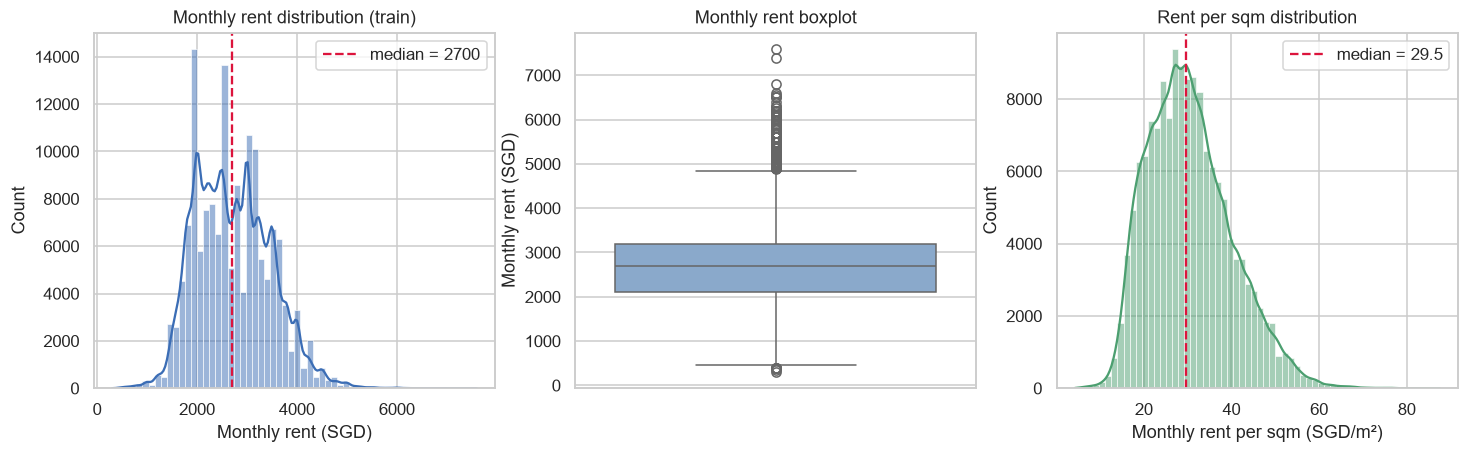

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.histplot(train["MONTHLY_RENT"], bins=60, kde=True, color="#3b6db5", ax=axes[0])
axes[0].axvline(train["MONTHLY_RENT"].median(), color="crimson", ls="--",
                label=f"median = {train['MONTHLY_RENT'].median():.0f}")
axes[0].set_title("Monthly rent distribution (train)")
axes[0].set_xlabel("Monthly rent (SGD)")
axes[0].legend()

sns.boxplot(y=train["MONTHLY_RENT"], color="#7fa8d6", ax=axes[1])
axes[1].set_title("Monthly rent boxplot")
axes[1].set_ylabel("Monthly rent (SGD)")

rps = train["MONTHLY_RENT"] / train["FLOOR_AREA_SQM"]
sns.histplot(rps, bins=60, kde=True, color="#4c9f70", ax=axes[2])
axes[2].axvline(rps.median(), color="crimson", ls="--", label=f"median = {rps.median():.1f}")
axes[2].set_title("Rent per sqm distribution")
axes[2].set_xlabel("Monthly rent per sqm (SGD/m²)")
axes[2].legend()

save(fig, "eda_rent_distribution.png")
plt.show()

## 3. Monthly Rent Trend

Median rent rose over the training period. March 2025 occurs in both sets;
the remaining test months run from April 2025 to July 2026, up to 16 months
beyond the final training month. Whole-month chronological validation should
evaluate this extrapolation horizon. Monthly medians also reflect changing property mix.

saved: outputs\figures\eda_monthly_trend.png


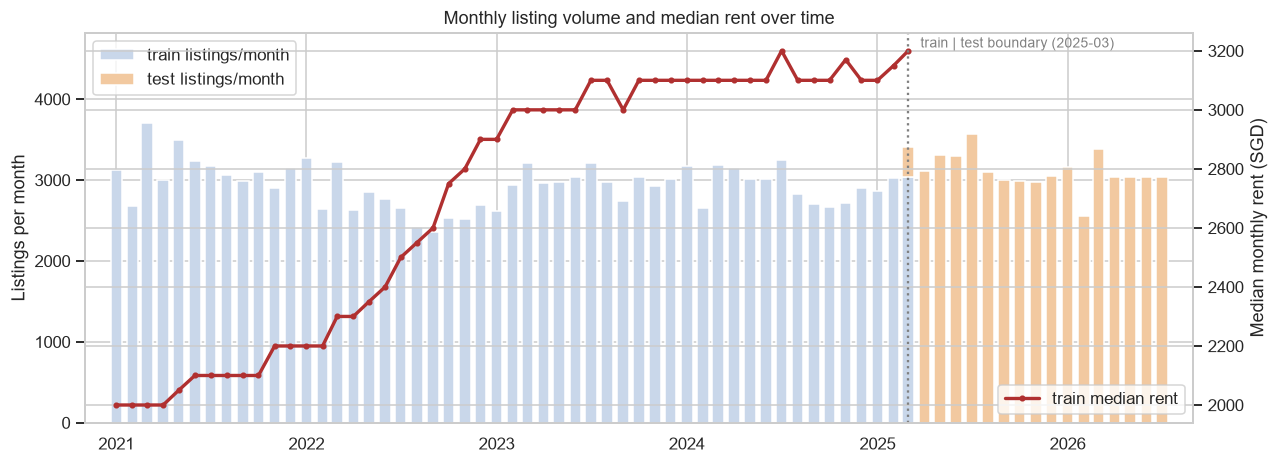

RENT_APPROVAL_YEAR,2021,2022,2023,2024,2025
median rent,2100.0,2450.0,3000.0,3100.0,3150.0


In [4]:
monthly = (train.groupby("RENT_APPROVAL_DATE")
           .agg(median_rent=("MONTHLY_RENT", "median"), n=("MONTHLY_RENT", "size")))
monthly.index = pd.to_datetime(monthly.index)  # real datetime axis for axvline/width
test_monthly = test.groupby("RENT_APPROVAL_DATE").size()
test_monthly.index = pd.to_datetime(test_monthly.index)

fig, ax1 = plt.subplots(figsize=(13, 4.6))

ax1.bar(monthly.index, monthly["n"], width=22, color="#c9d7ea", label="train listings/month")
ax1.bar(test_monthly.index, test_monthly.values, bottom=monthly["n"].reindex(test_monthly.index, fill_value=0), width=22, color="#f2c9a0", label="test listings/month")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["median_rent"], color="#b03030", lw=2.2, marker="o", ms=3,
         label="train median rent")
split = pd.Timestamp("2025-03-01")
ax2.axvline(split, color="gray", ls=":", lw=1.5)
ax2.annotate("train | test boundary (2025-03)", xy=(split, 0.99),
             xycoords=("data", "axes fraction"), xytext=(8, 0), textcoords="offset points",
             fontsize=9, color="gray", va="top")

# Set limits AFTER all plotting: twinx shares the x-axis, and later plot/axvline
# calls can re-autoscale away limits set earlier.
ax1.set_ylim(0, float(max(monthly["n"].max(), test_monthly.max())) * 1.30)  # legend headroom
ax1.set_xlim(min(monthly.index.min(), test_monthly.index.min()) - pd.Timedelta(days=60),
             max(monthly.index.max(), test_monthly.index.max()) + pd.Timedelta(days=60))
ax1.set_ylabel("Listings per month")
ax2.set_ylabel("Median monthly rent (SGD)")
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

ax1.set_title("Monthly listing volume and median rent over time")
save(fig, "eda_monthly_trend.png")
plt.show()

yearly = train.groupby("RENT_APPROVAL_YEAR")["MONTHLY_RENT"].median()
display(yearly.to_frame("median rent").T)

## 4. Town vs Rent

Compare both median rent and sample size. These are pooled descriptive differences,
confounded by flat type, area and approval date; they do not establish a causal location
premium or its stability over time. Sparse towns require cautious interpretation.

saved: outputs\figures\eda_town_rent.png


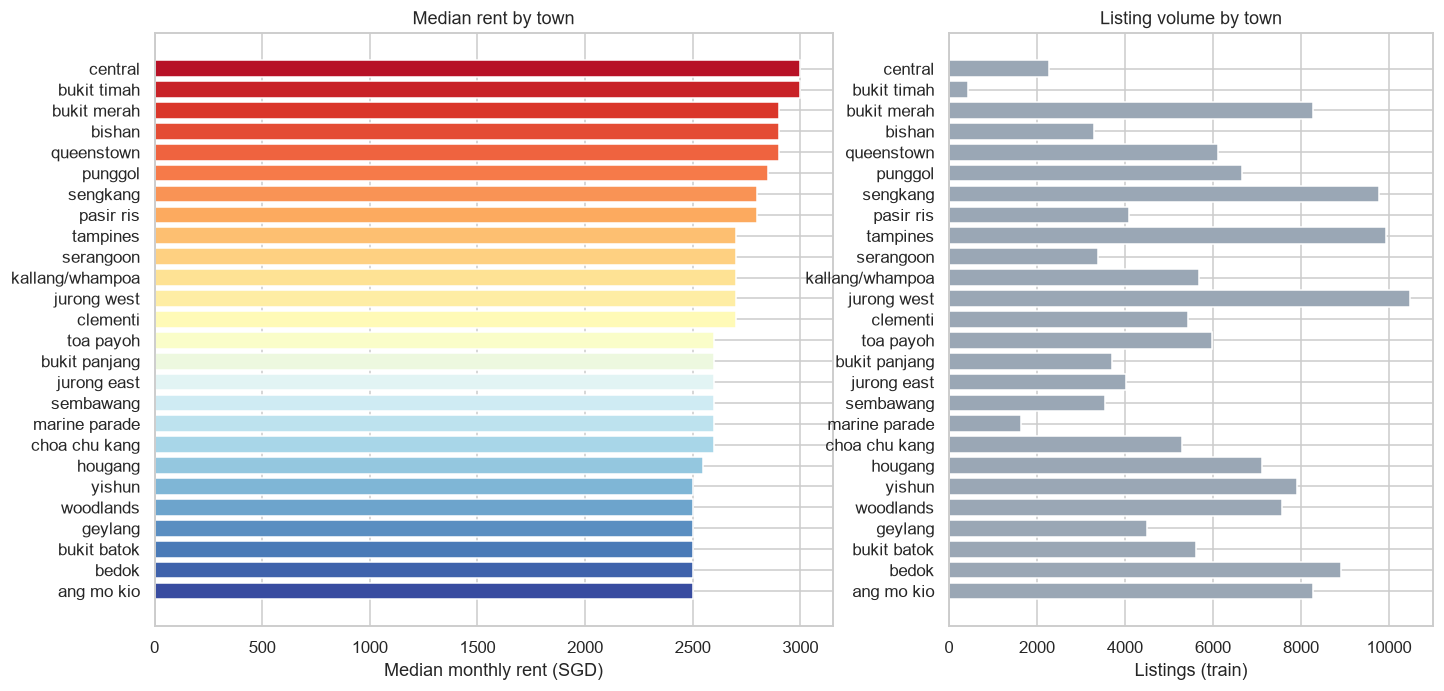

TOWN,ang mo kio,bedok,bukit batok,geylang,woodlands,yishun,hougang,choa chu kang,marine parade,sembawang,...,serangoon,tampines,pasir ris,sengkang,punggol,queenstown,bishan,bukit merah,bukit timah,central
median,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,2550.0,2600.0,2600.0,2600.0,...,2700.0,2700.0,2800.0,2800.0,2850.0,2900.0,2900.0,2900.0,3000.0,3000.0
n,8283.0,8907.0,5605.0,4504.0,7577.0,7913.0,7115.0,5300.0,1637.0,3553.0,...,3398.0,9942.0,4089.0,9773.0,6668.0,6115.0,3306.0,8270.0,438.0,2278.0


In [5]:
town = (train.groupby("TOWN")["MONTHLY_RENT"]
        .agg(median="median", n="size")
        .sort_values("median"))

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.4, 1]})

colors = sns.color_palette("RdYlBu_r", len(town))
axes[0].barh(town.index, town["median"], color=colors)
axes[0].set_xlabel("Median monthly rent (SGD)")
axes[0].set_title("Median rent by town")

axes[1].barh(town.index, town["n"], color="#9aa7b5")
axes[1].set_xlabel("Listings (train)")
axes[1].set_title("Listing volume by town")

save(fig, "eda_town_rent.png")
plt.show()
display(town.T.round(0))

## 5. Flat Type vs Rent

Larger flat types generally have higher total rents and lower rent per sqm.
The table provides sample sizes, which matter especially for 1-room flats and rare models.
The ratio includes area in its denominator, so its negative correlation with area is
not independent evidence of a causal bulk discount.

saved: outputs\figures\eda_flat_type_rent.png


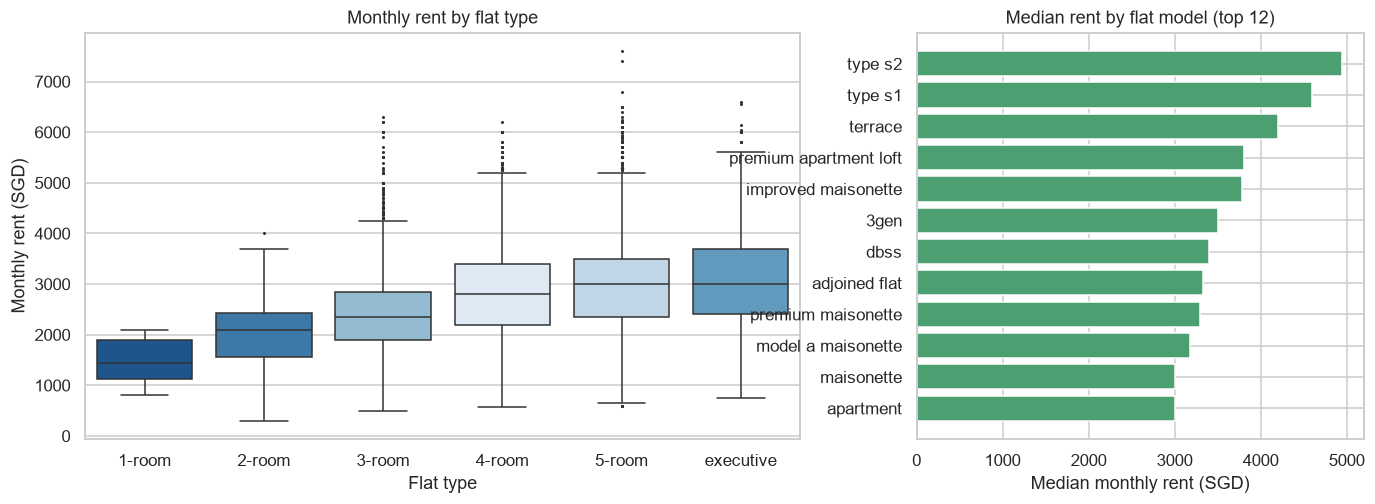

FLAT_TYPE,1-room,2-room,3-room,4-room,5-room,executive
n,42.0,3098.0,49024.0,54079.0,35523.0,8234.0
median_rent,1450.0,2100.0,2350.0,2800.0,3000.0,3000.0
median_rent_per_sqm,46.8,45.5,34.4,29.7,25.4,21.1


In [6]:
order = ["1-room", "2-room", "3-room", "4-room", "5-room", "executive"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.6, 1]})

sns.boxplot(data=train, x="FLAT_TYPE", y="MONTHLY_RENT", order=order,
            hue="FLAT_TYPE", legend=False, palette="Blues", fliersize=1, ax=axes[0])
axes[0].set_title("Monthly rent by flat type")
axes[0].set_xlabel("Flat type")
axes[0].set_ylabel("Monthly rent (SGD)")

model = (train.groupby("FLAT_MODEL")["MONTHLY_RENT"]
         .agg(median="median", n="size")
         .sort_values("median").tail(12))
axes[1].barh(model.index, model["median"], color="#4c9f70")
axes[1].set_title("Median rent by flat model (top 12)")
axes[1].set_xlabel("Median monthly rent (SGD)")

save(fig, "eda_flat_type_rent.png")
plt.show()

tbl = train.assign(rps=train["MONTHLY_RENT"] / train["FLOOR_AREA_SQM"])
display(tbl.groupby("FLAT_TYPE").agg(n=("MONTHLY_RENT", "size"),
                                     median_rent=("MONTHLY_RENT", "median"),
                                     median_rent_per_sqm=("rps", "median")).loc[order].T.round(1))

## 6. Floor Area vs Rent

Area has a positive marginal association with rent, with substantial dispersion.
Use the correlation table and binned sample sizes below; univariate associations
do not rank conditional predictive importance or justify removing area/flat type.

saved: outputs\figures\eda_floor_area_rent.png


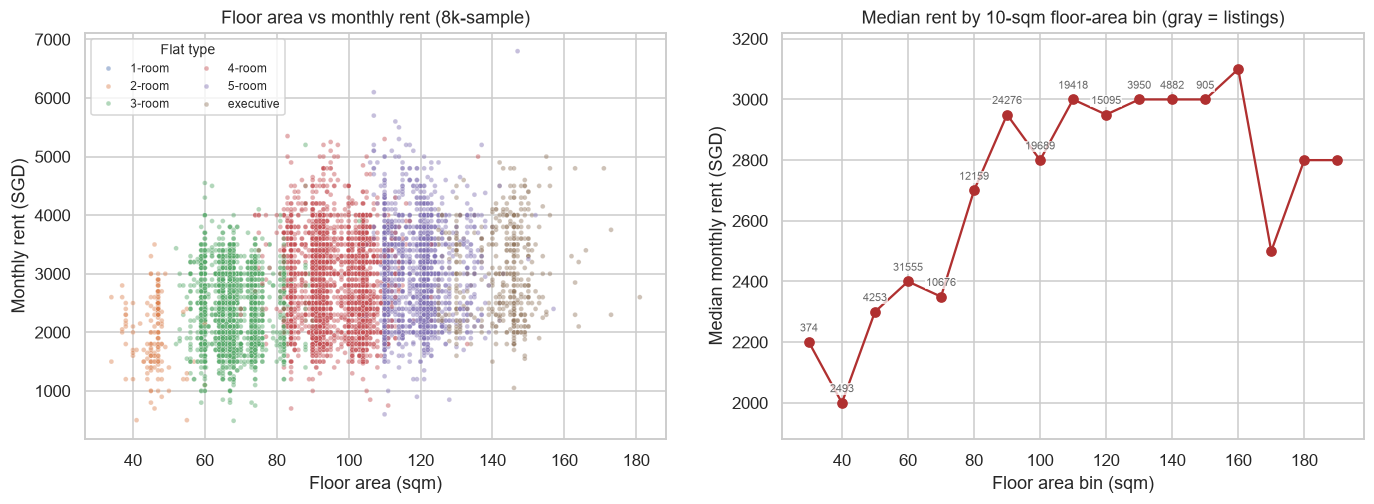

Spearman correlation with MONTHLY_RENT:
FLOOR_AREA_SQM        0.318
FLAT_AGE             -0.166
RENT_APPROVAL_YEAR    0.554
Pearson correlations:


FLOOR_AREA_SQM        0.329273
FLAT_AGE             -0.178141
RENT_APPROVAL_YEAR    0.517250
Name: MONTHLY_RENT, dtype: float64

Area ranges by flat type:


,min,median,max,size
FLAT_TYPE,,,,
1-room,31.0,31.0,31.0,42
2-room,34.0,47.0,67.0,3098
3-room,52.0,67.0,126.4,49024
4-room,70.0,93.0,145.0,54079
5-room,99.0,118.0,157.0,35523
executive,125.0,144.0,215.0,8234


In [7]:
rng = np.random.default_rng(42)
sample = train.sample(8_000, random_state=rng.integers(1 << 31))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

sns.scatterplot(data=sample, x="FLOOR_AREA_SQM", y="MONTHLY_RENT", hue="FLAT_TYPE",
                hue_order=order, s=10, alpha=0.45, legend=True, ax=axes[0])
axes[0].set_title("Floor area vs monthly rent (8k-sample)")
axes[0].set_xlabel("Floor area (sqm)")
axes[0].set_ylabel("Monthly rent (SGD)")
axes[0].legend(title="Flat type", fontsize=8, title_fontsize=9, loc="upper left", ncols=2)

binned = (train.assign(area_bin=(train["FLOOR_AREA_SQM"] // 10) * 10)
          .query("area_bin >= 30 & area_bin <= 200")
          .groupby("area_bin")["MONTHLY_RENT"].agg(["median", "size"]).reset_index())
axes[1].plot(binned["area_bin"], binned["median"], marker="o", color="#b03030")
for _, r in binned.iterrows():
    if r["size"] > 300:
        axes[1].annotate(f"{int(r['size'])}", (r["area_bin"], r["median"]),
                         xytext=(0, 7), textcoords="offset points", fontsize=7, color="dimgray",
                         ha="center", zorder=3,
                         bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.5))
axes[1].set_ylim(binned["median"].min() - 120, binned["median"].max() + 120)
axes[1].set_title("Median rent by 10-sqm floor-area bin (gray = listings)")
axes[1].set_xlabel("Floor area bin (sqm)")
axes[1].set_ylabel("Median monthly rent (SGD)")

save(fig, "eda_floor_area_rent.png")
plt.show()

cols = ["FLOOR_AREA_SQM", "FLAT_AGE", "RENT_APPROVAL_YEAR", "MONTHLY_RENT"]
corr = train[cols].corr(method="spearman")["MONTHLY_RENT"].drop("MONTHLY_RENT")
print("Spearman correlation with MONTHLY_RENT:")
print(corr.round(3).to_string())
print("Pearson correlations:")
display(train[cols].corr()["MONTHLY_RENT"].drop("MONTHLY_RENT"))
print("Area ranges by flat type:")
display(train.groupby("FLAT_TYPE").FLOOR_AREA_SQM.agg(["min", "median", "max", "size"]))

## 7. Flat Age vs Rent

The pooled age-rent association is non-monotonic and potentially confounded by
flat type, town and date. Lease commencement age is not necessarily building age.
The negative age record is included in the first bucket and remains flagged in the audit.
The sampled line explicitly estimates the median; the band is the 25th–75th
percentile of observed rent, not a confidence interval for that median.

saved: outputs\figures\eda_flat_age_rent.png


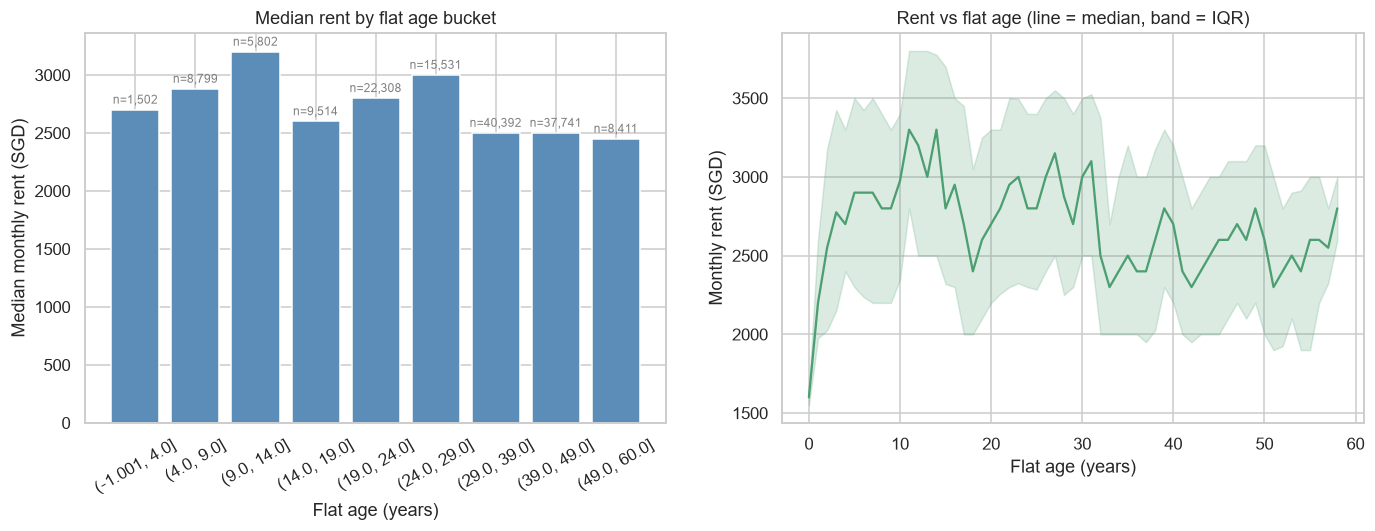

,0,1,2,3,4,5,6,7,8
age_bucket,"(-1.001, 4.0]","(4.0, 9.0]","(9.0, 14.0]","(14.0, 19.0]","(19.0, 24.0]","(24.0, 29.0]","(29.0, 39.0]","(39.0, 49.0]","(49.0, 60.0]"
median,2700.0,2880.0,3200.0,2600.0,2800.0,3000.0,2500.0,2500.0,2450.0
n,1502,8799,5802,9514,22308,15531,40392,37741,8411


In [8]:
age_tbl = (train.assign(age_bucket=pd.cut(train["FLAT_AGE"], [-1, 4, 9, 14, 19, 24, 29, 39, 49, 60], include_lowest=True))
           .groupby("age_bucket", observed=True)["MONTHLY_RENT"]
           .agg(median="median", n="size").reset_index())
labels = age_tbl["age_bucket"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

axes[0].bar(labels, age_tbl["median"], color="#5b8db8")
for i, r in age_tbl.iterrows():
    axes[0].annotate(f"n={r['n']:,}", (i, r["median"]), xytext=(0, 4),
                     textcoords="offset points", ha="center", fontsize=8, color="gray")
axes[0].set_title("Median rent by flat age bucket")
axes[0].set_xlabel("Flat age (years)")
axes[0].set_ylabel("Median monthly rent (SGD)")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(data=train.sample(20_000, random_state=1), x="FLAT_AGE", y="MONTHLY_RENT",
             estimator="median", errorbar=("pi", 50), color="#4c9f70", ax=axes[1])
axes[1].set_title("Rent vs flat age (line = median, band = IQR)")
axes[1].set_xlabel("Flat age (years)")
axes[1].set_ylabel("Monthly rent (SGD)")

save(fig, "eda_flat_age_rent.png")
plt.show()
display(age_tbl.T)
assert age_tbl["n"].sum() == len(train)


## 8. Train / Test Distribution Differences

Several marginal distributions look similar, but that does not rule out joint or
conditional distribution shift. A small absolute change in a rare category can still
be a large relative change. March 2025 overlaps; most test rows are in later months.
Inspect unseen categories and block coverage in `outputs/audit.json` as well as these plots.

saved: outputs\figures\eda_train_test_diff.png


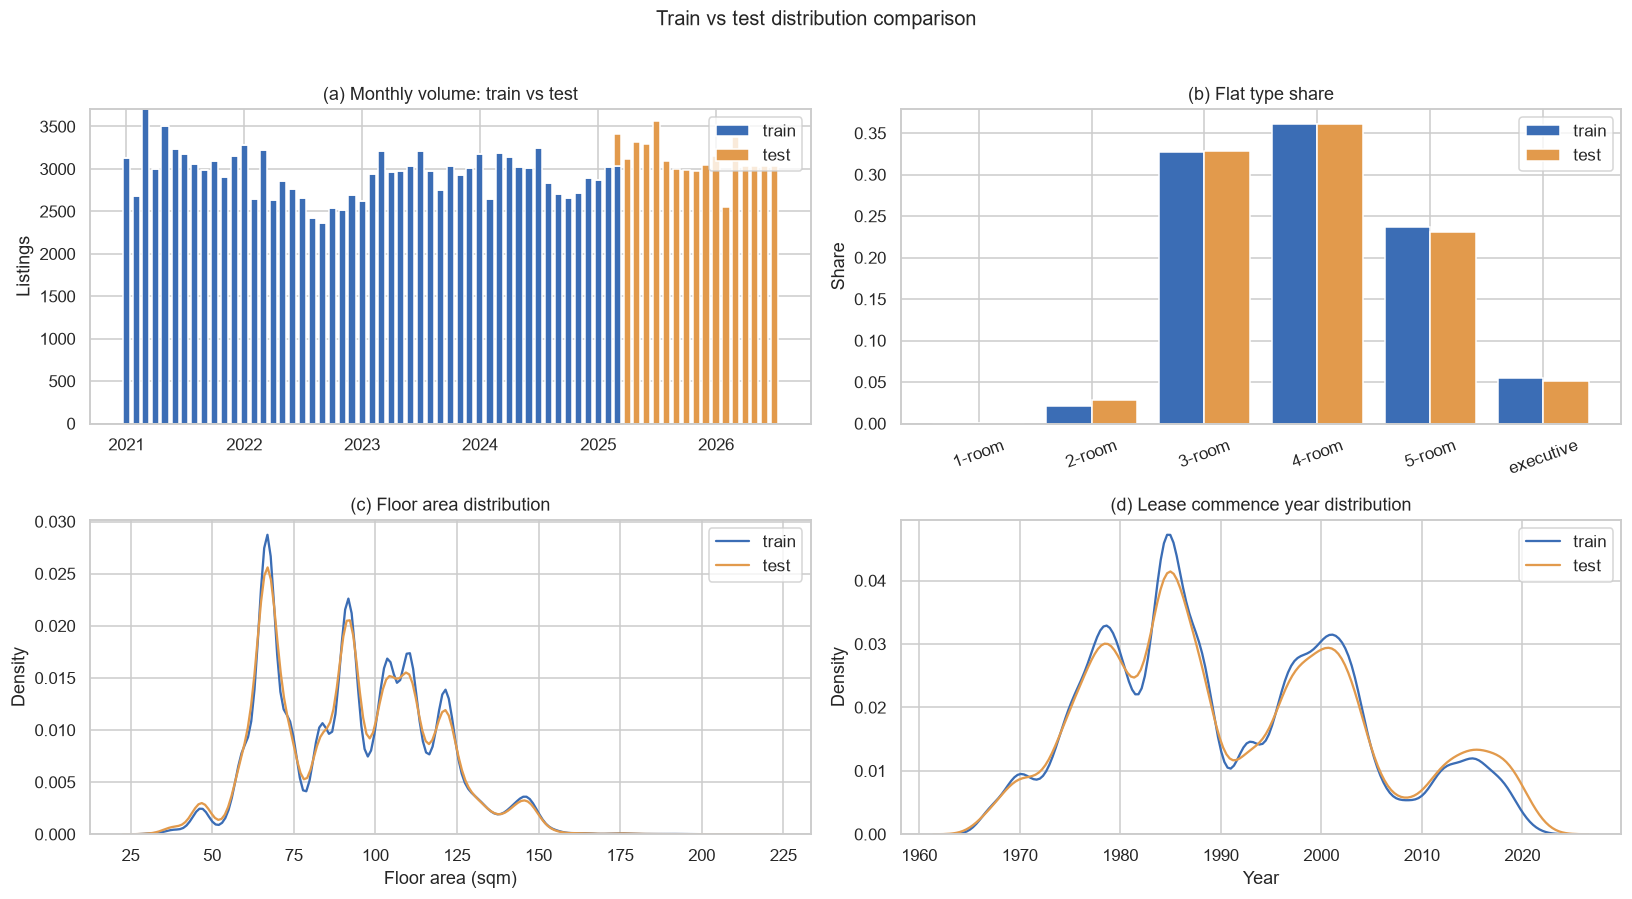

,train,test,abs diff
TOWN,,,
bukit batok,0.0374,0.0411,0.0038
jurong west,0.0699,0.0733,0.0034
bedok,0.0594,0.0561,0.0033
woodlands,0.0505,0.0477,0.0028
bishan,0.022,0.0196,0.0024


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# (a) monthly volume, train vs test
monthly_all = pd.concat([
    train.assign(split="train"), test.assign(split="test")
]).groupby(["RENT_APPROVAL_DATE", "split"]).size().rename("n").reset_index()
piv = monthly_all.pivot(index="RENT_APPROVAL_DATE", columns="split", values="n").fillna(0)
piv.index = pd.to_datetime(piv.index)
axes[0, 0].bar(piv.index, piv.get("train", 0), width=22, color="#3b6db5", label="train")
axes[0, 0].bar(piv.index, piv.get("test", 0), bottom=piv.get("train", 0), width=22, color="#e29a4c", label="test")
axes[0, 0].set_title("(a) Monthly volume: train vs test")
axes[0, 0].set_ylabel("Listings")
axes[0, 0].legend()

# (b) flat type proportions
prop = pd.concat({"train": train["FLAT_TYPE"].value_counts(normalize=True),
                  "test": test["FLAT_TYPE"].value_counts(normalize=True)}, axis=1).loc[order]
x = np.arange(len(prop))
axes[0, 1].bar(x - 0.2, prop["train"], width=0.4, color="#3b6db5", label="train")
axes[0, 1].bar(x + 0.2, prop["test"], width=0.4, color="#e29a4c", label="test")
axes[0, 1].set_xticks(x, prop.index, rotation=20)
axes[0, 1].set_title("(b) Flat type share")
axes[0, 1].set_ylabel("Share")
axes[0, 1].legend()

# (c) floor area distribution
sns.kdeplot(train["FLOOR_AREA_SQM"], label="train", color="#3b6db5", ax=axes[1, 0])
sns.kdeplot(test["FLOOR_AREA_SQM"], label="test", color="#e29a4c", ax=axes[1, 0])
axes[1, 0].set_title("(c) Floor area distribution")
axes[1, 0].set_xlabel("Floor area (sqm)")
axes[1, 0].legend()

# (d) lease commence year distribution
sns.kdeplot(train["LEASE_COMMENCE_DATE"], label="train", color="#3b6db5", ax=axes[1, 1])
sns.kdeplot(test["LEASE_COMMENCE_DATE"], label="test", color="#e29a4c", ax=axes[1, 1])
axes[1, 1].set_title("(d) Lease commence year distribution")
axes[1, 1].set_xlabel("Year")
axes[1, 1].legend()

fig.suptitle("Train vs test distribution comparison", y=1.02, fontsize=13)
fig.tight_layout()
save(fig, "eda_train_test_diff.png")
plt.show()

town_prop = pd.concat({"train": train["TOWN"].value_counts(normalize=True),
                       "test": test["TOWN"].value_counts(normalize=True)}, axis=1)
town_prop["abs diff"] = (town_prop["train"] - town_prop["test"]).abs()
display(town_prop.sort_values("abs diff", ascending=False).head(5).round(4))

## 9. Summary & Implications for Modelling

1. Use whole-month chronological holdouts, including a long horizon resembling the
   16 future test months. Report RMSE in SGD, including per-month and subgroup errors.
2. Preserve transaction frequency by default. Compare optional training deduplication
   on the same untouched validation rows; never deduplicate the test set.
3. Keep nonlinear age/area effects as hypotheses. Pooled EDA establishes associations,
   not causality, noise floors, or the best model.
4. HDB joins must validate many-to-one cardinality, preserve row order and row count.
   Current MRT status lacks opening dates, so it cannot reconstruct historical accessibility.
5. Stock data have missing prices and uneven series coverage. Monthly macro information
   must obey the stated prediction cutoff; never backfill from future observations.
6. Fit imputation, scaling and target encoding inside each training fold. Do not use
   rent per sqm as an input. Test covariates support schema/coverage checks only.

### Next steps

Start with global mean and recent town/flat-type mean baselines, followed by a regularized
linear model and a tree model. Keep the same temporal folds for feature and deduplication
ablations. This notebook completes stage-one EDA; it does not claim model quality or
replace the progress/final reports. Evaluate these modelling choices using chronological validation.